In [25]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import warnings
import os

warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs('../report/images', exist_ok=True)

In [26]:
train = pd.read_csv('../data/raw/train.csv')
train.shape

(200000, 202)

In [27]:
train.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [28]:
print('пропуски:', train.isnull().sum().sum())
print('дубликаты:', train.duplicated().sum())
train.dtypes.value_counts()

пропуски: 0
дубликаты: 0


float64    200
object       1
int64        1
Name: count, dtype: int64

In [29]:
train.describe().T[['mean','std','min','max']].head(10)

,mean,std,min,max
target,0.100490,0.300653,0.0000,1.0000
var_0,10.679914,3.040051,0.4084,20.3150
var_1,-1.627622,4.050044,-15.0434,10.3768
var_2,10.715192,2.640894,2.1171,19.3530
var_3,6.796529,2.043319,-0.0402,13.1883
var_4,11.078333,1.623150,5.0748,16.6714
var_5,-5.065317,7.863267,-32.5626,17.2516
var_6,5.408949,0.866607,2.3473,8.4477
var_7,16.545850,3.418076,5.3497,27.6918
var_8,0.284162,3.332634,-10.5055,10.1513


In [30]:
vc = train['target'].value_counts()
print(vc)
print(train['target'].value_counts(normalize=True))

target
0    179902
1     20098
Name: count, dtype: int64
target
0    0.89951
1    0.10049
Name: proportion, dtype: float64


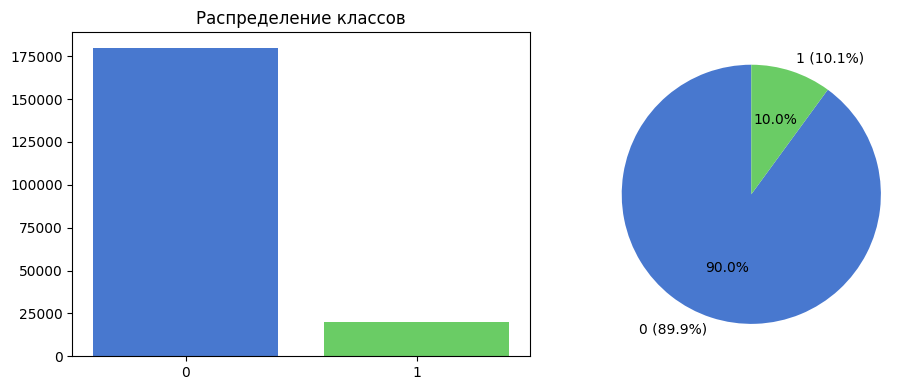

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['0', '1'], vc.values, color=['#4878CF', '#6ACC65'])
axes[0].set_title('Распределение классов')

axes[1].pie(vc.values, labels=['0 (89.9%)', '1 (10.1%)'], colors=['#4878CF', '#6ACC65'],
            autopct='%1.1f%%', startangle=90)

plt.tight_layout()
plt.savefig('../report/images/target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

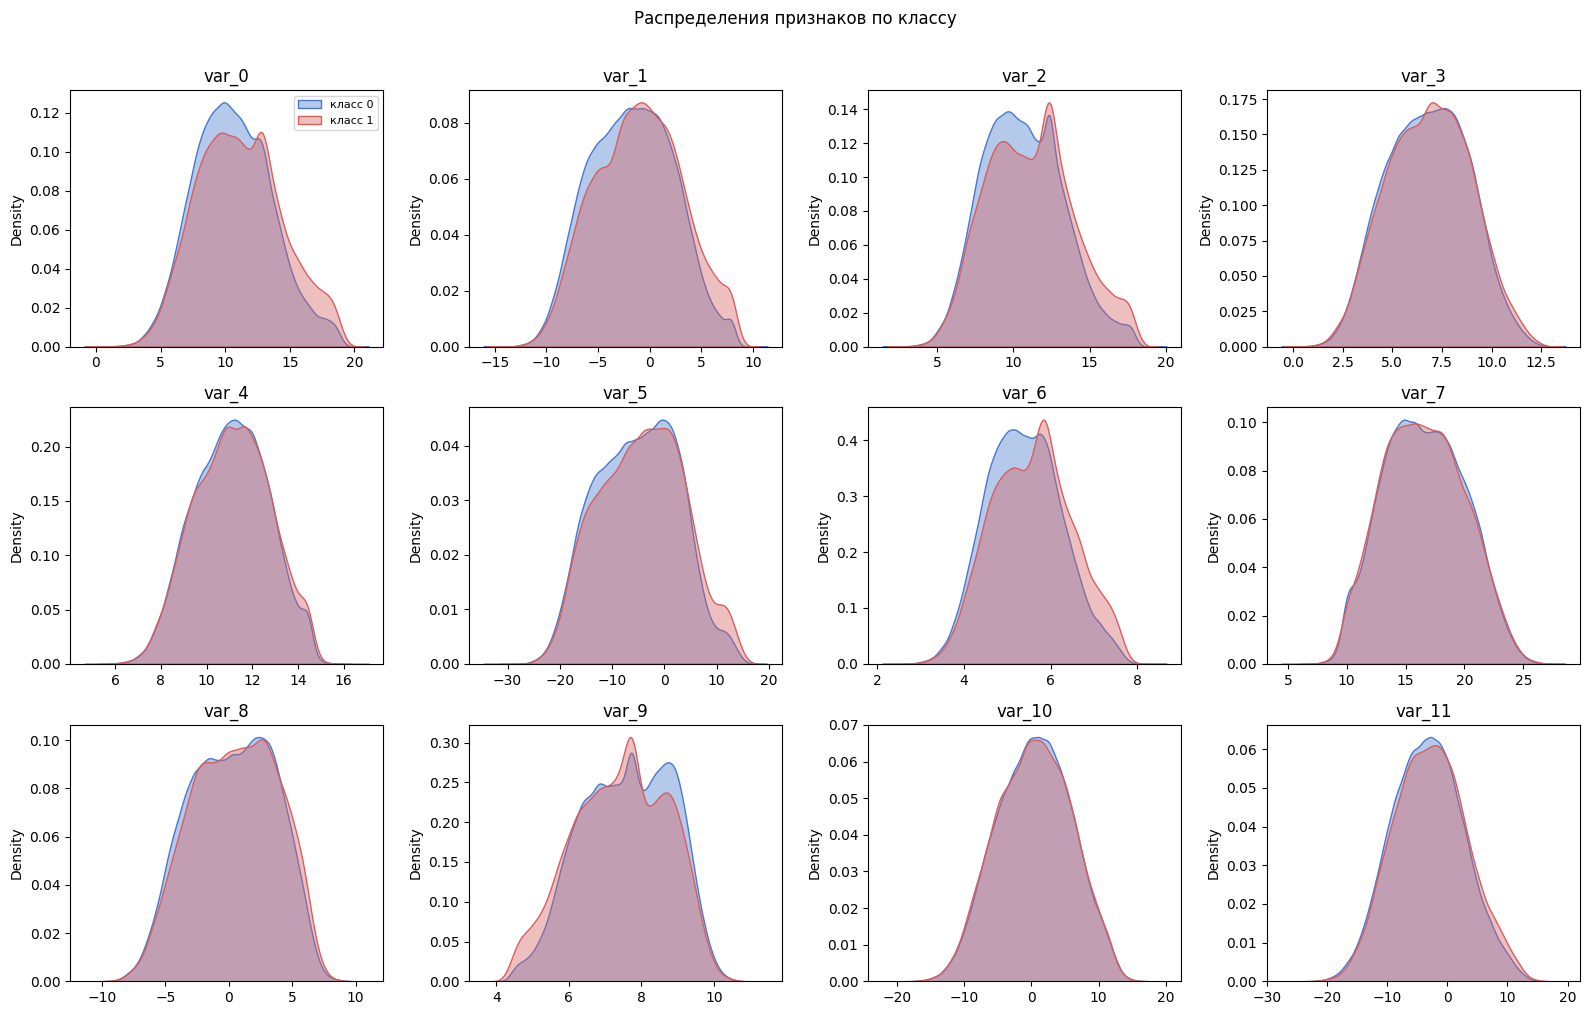

In [32]:
feat_cols = [f'var_{i}' for i in range(200)]
sample_vars = feat_cols[:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(sample_vars):
    for cls, color, label in [(0, '#4878CF', 'класс 0'), (1, '#D65F5F', 'класс 1')]:
        sns.kdeplot(train.loc[train['target'] == cls, col],
                    color=color, label=label, fill=True, alpha=0.4, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Распределения признаков по классу', y=1.01)
plt.tight_layout()
plt.savefig('../report/images/feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

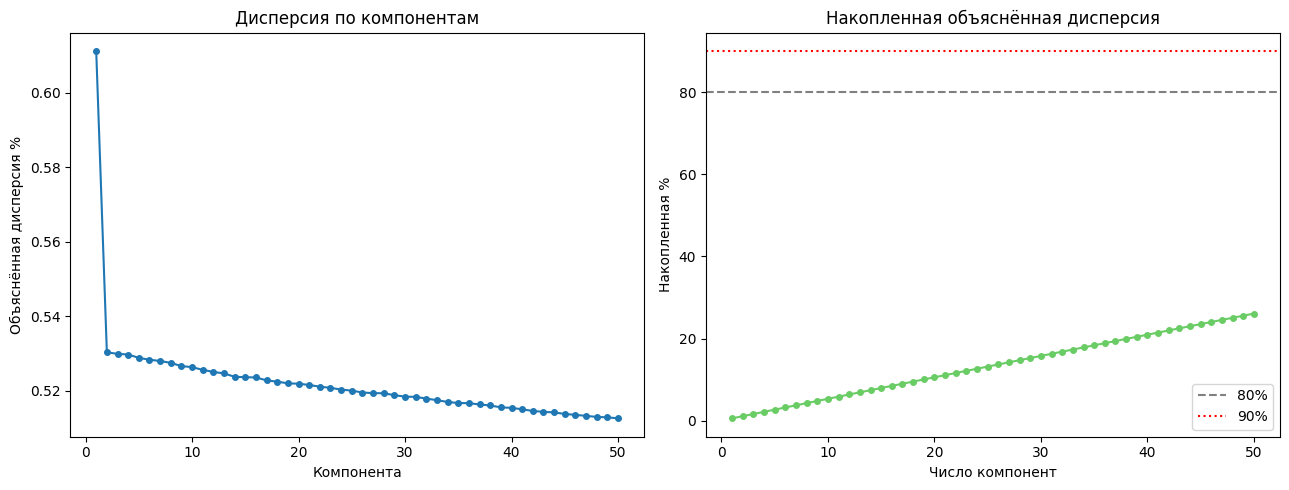

компонент для 80%: 51
компонент для 90%: 51


In [33]:
X = train[feat_cols].values
y = train['target'].values

X_scaled = StandardScaler().fit_transform(X)

pca50 = PCA(n_components=50, random_state=42).fit(X_scaled)
cumvar = np.cumsum(pca50.explained_variance_ratio_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(range(1, 51), pca50.explained_variance_ratio_ * 100, 'o-', ms=4)
ax1.set_xlabel('Компонента')
ax1.set_ylabel('Объяснённая дисперсия %')
ax1.set_title('Дисперсия по компонентам')

ax2.plot(range(1, 51), cumvar * 100, 'o-', ms=4, color='#6ACC65')
ax2.axhline(80, ls='--', color='gray', label='80%')
ax2.axhline(90, ls=':', color='red', label='90%')
ax2.set_xlabel('Число компонент')
ax2.set_ylabel('Накопленная %')
ax2.set_title('Накопленная объяснённая дисперсия')
ax2.legend()

plt.tight_layout()
plt.savefig('../report/images/pca_variance.png', dpi=120, bbox_inches='tight')
plt.show()

print('компонент для 80%:', np.searchsorted(cumvar, 0.80) + 1)
print('компонент для 90%:', np.searchsorted(cumvar, 0.90) + 1)

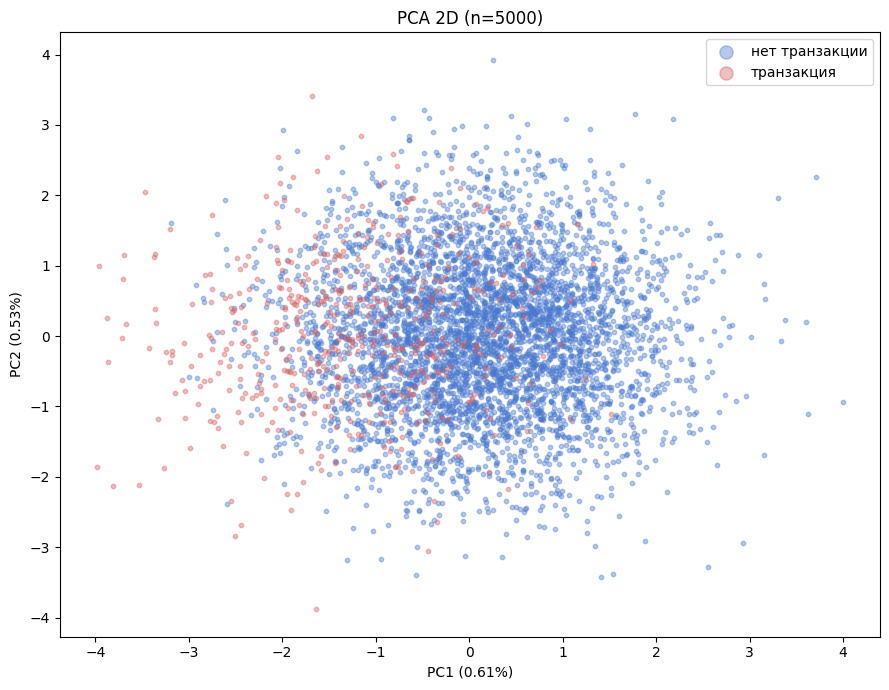

In [34]:
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

idx = np.random.choice(len(y), 5000, replace=False)

fig, ax = plt.subplots(figsize=(9, 7))
for cls, color, label in [(0, '#4878CF', 'нет транзакции'), (1, '#D65F5F', 'транзакция')]:
    m = y[idx] == cls
    ax.scatter(X_pca2[idx][m, 0], X_pca2[idx][m, 1], c=color, label=label, alpha=0.4, s=10)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.2f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.2f}%)')
ax.set_title('PCA 2D (n=5000)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('../report/images/pca_2d.png', dpi=120, bbox_inches='tight')
plt.show()

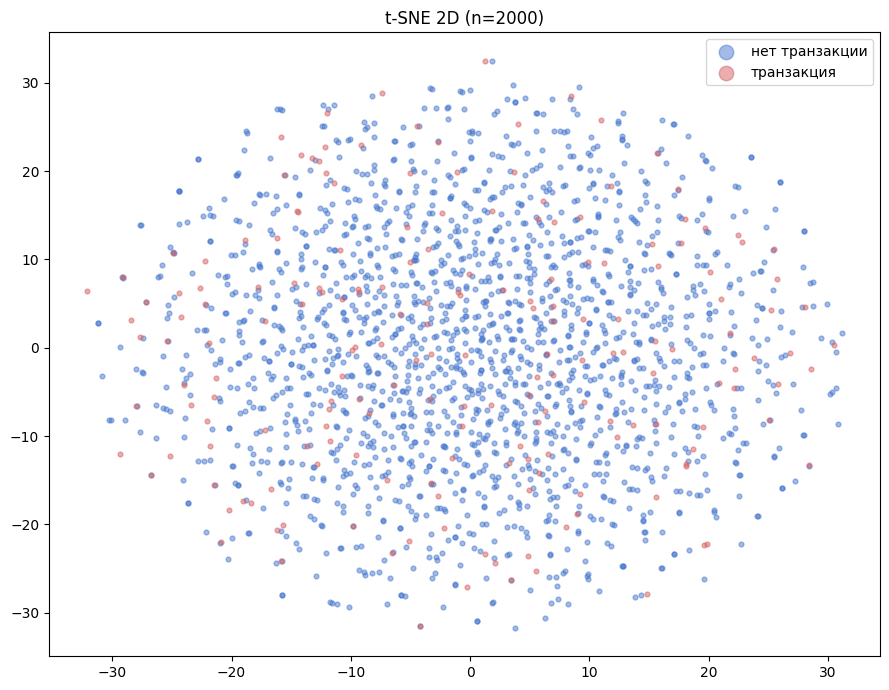

In [35]:
N = 2000
idx_t = np.random.choice(len(y), N, replace=False)
X_sub = PCA(n_components=50, random_state=42).fit_transform(X_scaled[idx_t])

X_tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(X_sub)

fig, ax = plt.subplots(figsize=(9, 7))
for cls, color, label in [(0, '#4878CF', 'нет транзакции'), (1, '#D65F5F', 'транзакция')]:
    m = y[idx_t] == cls
    ax.scatter(X_tsne[m, 0], X_tsne[m, 1], c=color, label=label, alpha=0.5, s=12)
ax.set_title(f't-SNE 2D (n={N})')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('../report/images/tsne_2d.png', dpi=120, bbox_inches='tight')
plt.show()

признаков с выбросами: 196
всего выбросов: 11299


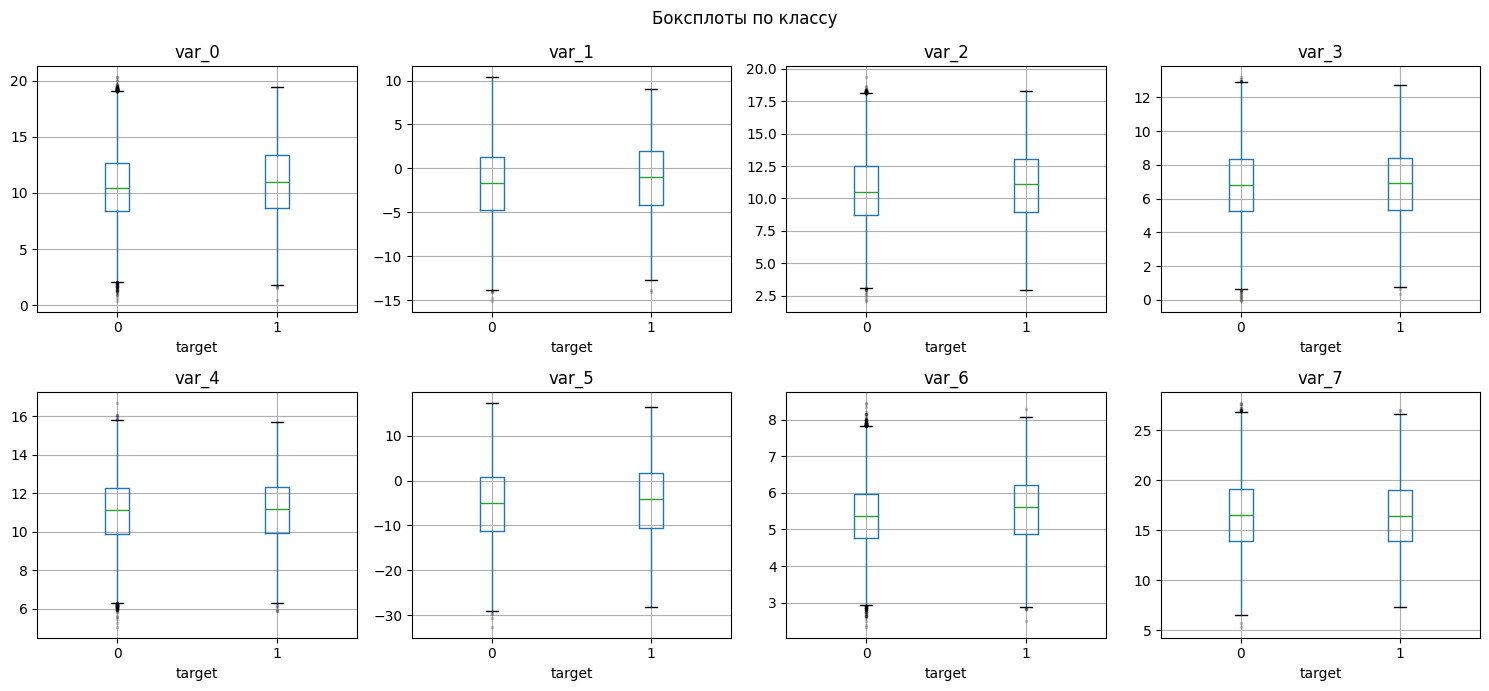

In [36]:
z = np.abs((train[feat_cols] - train[feat_cols].mean()) / train[feat_cols].std())
out = (z > 3).sum()
print('признаков с выбросами:', (out > 0).sum())
print('всего выбросов:', out.sum())

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()
for i, col in enumerate(feat_cols[:8]):
    train.boxplot(column=col, by='target', ax=axes[i],
                  flierprops=dict(marker='.', alpha=0.2, ms=3))
    axes[i].set_title(col)
plt.suptitle('Боксплоты по классу')
plt.tight_layout()
plt.savefig('../report/images/boxplots.png', dpi=120, bbox_inches='tight')
plt.show()